In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv("/content/drive/MyDrive/archive/olympics_dataset.csv")
df.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
0,0,A Dijiang,M,China,CHN,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,No medal
1,1,A Lamusi,M,China,CHN,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,No medal
2,2,Gunnar Aaby,M,Denmark,DEN,1920,Summer,Antwerpen,Football,Football Men's Football,No medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,26,Cornelia (-strannood),F,Netherlands,NED,1932,Summer,Los Angeles,Athletics,Athletics Women's 100 metres,No medal


In [7]:
medal_df = df[df['Medal'] != 'No medal']
medal_df.head()

,player_id,Name,Sex,Team,NOC,Year,Season,City,Sport,Event,Medal
3,3,Edgar Aabye,M,Denmark/Sweden,DEN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
12,37,Arvo Aaltonen,M,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 200 metres Breaststroke,Bronze
13,38,Arvo Aaltonen,M,Finland,FIN,1920,Summer,Antwerpen,Swimming,Swimming Men's 400 metres Breaststroke,Bronze
15,41,Paavo Aaltonen,M,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
16,42,Paavo Aaltonen,M,Finland,FIN,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold


In [13]:
country_medals = medal_df.groupby('Team')['Medal'].count().sort_values(ascending=False)
country_medals.head()

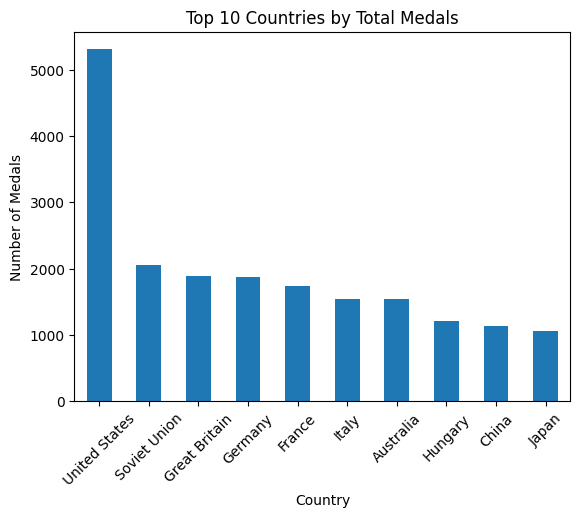

In [16]:
top10 = country_medals.head(10)
top10.plot(kind='bar')
plt.title("Top 10 Countries by Total Medals")
plt.xlabel("Country")
plt.ylabel("Number of Medals")
plt.xticks(rotation=45)
plt.show()

In [17]:
medal_breakdown = medal_df.groupby(['Team', 'Medal']).size().unstack().fillna(0)
medal_breakdown.head()

Medal,Bronze,Gold,Silver
Team,,,
A North American Team,4.0,0.0,0.0
AIN,1.0,1.0,4.0
Afghanistan,2.0,0.0,0.0
Albania,2.0,0.0,0.0
Algeria,9.0,7.0,4.0


In [18]:
gold_medals = medal_df[medal_df['Medal'] == 'Gold']
top_gold = gold_medals.groupby('Team').size().sort_values(ascending=False)

top_gold.head(10)

,0
Team,
United States,2577
Soviet Union,830
Germany,606
Great Britain,561
Italy,545
France,539
Hungary,450
China,424
Australia,405


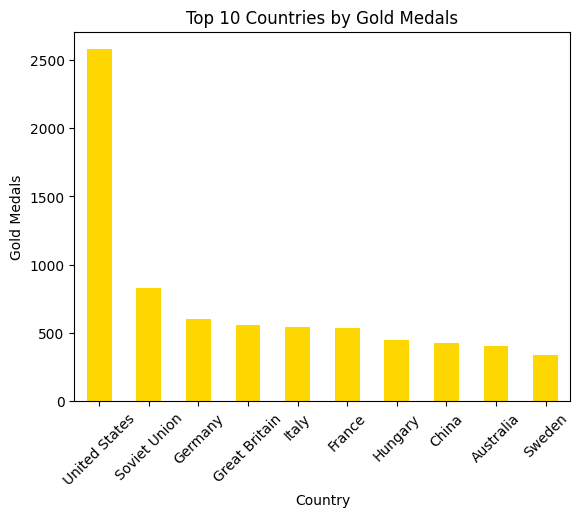

In [19]:
top_gold.head(10).plot(kind='bar', color='gold')
plt.title("Top 10 Countries by Gold Medals")
plt.xlabel("Country")
plt.ylabel("Gold Medals")
plt.xticks(rotation=45)
plt.show()

In [20]:
total = medal_df.groupby('Team').size()
gold = medal_df[medal_df['Medal'] == 'Gold'].groupby('Team').size()

efficiency = (gold / total).sort_values(ascending=False)
efficiency.head(10)

,0
Team,
Ancora,1.0
Amateur Athletic Association,1.0
Angelita,1.0
Atalanta Boat Club-1,1.0
Atlanta,1.0
Cercle de l'Aviron Roubaix-4,1.0
Carabinier-15,1.0
Camille,1.0
Bissbi,1.0
